# 📞 Task 3: Customer Churn Data Preparation & EDA
### Telecom Customer Churn Dataset
---
**Objective:** Prepare customer data for modeling using cleaning, feature engineering, and EDA.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


## 1. 📊 Data Understanding

In [2]:
df = pd.read_csv('telco_churn_raw.csv')
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())


Shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
print("=== Dataset Info ===")
df.info()


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null 

In [4]:
print("=== Statistical Summary ===")
df.describe()


=== Statistical Summary ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.159165,35.431776,68.194528
std,0.365856,20.693459,28.734013
min,0.000000,0.000000,18.010000
25%,0.000000,18.000000,43.980000
50%,0.000000,35.000000,68.520000
75%,0.000000,53.000000,92.815000
max,1.000000,71.000000,117.980000


In [5]:
print("=== Missing Values / Blanks ===")
# Check for actual NaN
print("NaN counts:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Check for whitespace strings (the Kaggle TotalCharges issue)
print("\nWhitespace strings in TotalCharges:", (df['TotalCharges'] == ' ').sum())
print("Empty strings in TotalCharges:", (df['TotalCharges'] == '').sum())

# Unique values sample
print("\nTotalCharges dtype:", df['TotalCharges'].dtype)
print("Sample TotalCharges values:", df['TotalCharges'].head(5).tolist())


=== Missing Values / Blanks ===
NaN counts:
TotalCharges    95
dtype: int64

Whitespace strings in TotalCharges: 134
Empty strings in TotalCharges: 0

TotalCharges dtype: str
Sample TotalCharges values: ['3570.17', ' ', '1381.46', '5758.6', '1073.31']


## 2. 🧹 Data Cleaning

In [6]:
# Fix TotalCharges: replace spaces/empty with NaN, then convert to float
df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("TotalCharges dtype after fix:", df['TotalCharges'].dtype)
print("NaN in TotalCharges:", df['TotalCharges'].isnull().sum())


TotalCharges dtype after fix: float64
NaN in TotalCharges: 229


In [7]:
# Handle missing values in TotalCharges
# Customers with tenure=0 likely have TotalCharges=0 (just joined)
df.loc[(df['tenure'] == 0) & (df['TotalCharges'].isnull()), 'TotalCharges'] = 0.0

# For remaining NaNs, impute with median
median_tc = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_tc, inplace=True)

print(f"After imputation — NaN in TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(f"Median used for imputation: {median_tc:.2f}")


After imputation — NaN in TotalCharges: 134
Median used for imputation: 1949.06


In [8]:
# Verify data types
print("=== Data Types After Cleaning ===")
print(df.dtypes)

# Check for any remaining issues
print("\n=== Null counts after cleaning ===")
print(df.isnull().sum())


=== Data Types After Cleaning ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

=== Null counts after cleaning ===
customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV     

## 3. ⚙️ Feature Engineering

In [9]:
# 3a. TenureGroup — segment customers into tenure buckets
def tenure_group(t):
    if t <= 12:  return '0-12 months'
    elif t <= 24: return '13-24 months'
    elif t <= 36: return '25-36 months'
    elif t <= 48: return '37-48 months'
    elif t <= 60: return '49-60 months'
    else:         return '61+ months'

df['TenureGroup'] = df['tenure'].apply(tenure_group)
print("TenureGroup distribution:")
print(df['TenureGroup'].value_counts())


TenureGroup distribution:
TenureGroup
0-12 months     1247
13-24 months    1222
49-60 months    1186
37-48 months    1177
25-36 months    1157
61+ months      1054
Name: count, dtype: int64


In [10]:
# 3b. AvgMonthlySpend = TotalCharges / tenure (avoid division by zero)
df['AvgMonthlySpend'] = np.where(
    df['tenure'] > 0,
    df['TotalCharges'] / df['tenure'],
    df['MonthlyCharges']   # use MonthlyCharges if tenure=0
)
df['AvgMonthlySpend'] = df['AvgMonthlySpend'].round(2)
print("AvgMonthlySpend stats:")
print(df['AvgMonthlySpend'].describe())


AvgMonthlySpend stats:


count    6909.000000
mean       68.072026
std        28.772725
min        15.950000
25%        43.800000
50%        68.310000
75%        92.710000
max       136.880000
Name: AvgMonthlySpend, dtype: float64


In [11]:
# 3c. Convert binary Yes/No columns to 1/0
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for col in binary_cols:
    df[col+'_enc'] = df[col].map({'Yes':1,'No':0})

# SeniorCitizen is already 0/1
print("Binary encoding done.")
print(df[['Churn','Churn_enc']].head())


Binary encoding done.
  Churn  Churn_enc
0   Yes          1
1    No          0
2    No          0
3   Yes          1
4    No          0


In [12]:
# 3d. One-hot encode Contract and InternetService
df_encoded = pd.get_dummies(df, columns=['Contract','InternetService'], drop_first=False)

# Show new columns added
new_cols = [c for c in df_encoded.columns if 'Contract_' in c or 'InternetService_' in c]
print("One-hot encoded columns:")
print(new_cols)
print("\nDataset shape after encoding:", df_encoded.shape)


One-hot encoded columns:
['Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No']

Dataset shape after encoding: (7043, 32)


In [13]:
# 3e. Preview the fully engineered dataset
print("=== Engineered Features Preview ===")
df[['customerID','tenure','TenureGroup','MonthlyCharges','TotalCharges','AvgMonthlySpend','Churn']].head(10)


=== Engineered Features Preview ===


,customerID,tenure,TenureGroup,MonthlyCharges,TotalCharges,AvgMonthlySpend,Churn
0,C-00001,51,49-60 months,70.02,3570.17,70.00,Yes
1,C-00002,14,13-24 months,74.57,NaN,NaN,No
2,C-00003,71,61+ months,19.53,1381.46,19.46,No
3,C-00004,60,49-60 months,96.06,5758.60,95.98,Yes
4,C-00005,20,13-24 months,54.16,1073.31,53.67,No
5,C-00006,23,13-24 months,58.64,1340.38,58.28,No
6,C-00007,2,0-12 months,98.94,188.16,94.08,No
7,C-00008,21,13-24 months,55.93,1180.26,56.20,No
8,C-00009,52,49-60 months,22.72,1184.50,22.78,Yes
9,C-00010,1,0-12 months,35.64,35.91,35.91,No


## 4. 📈 EDA & Visualization

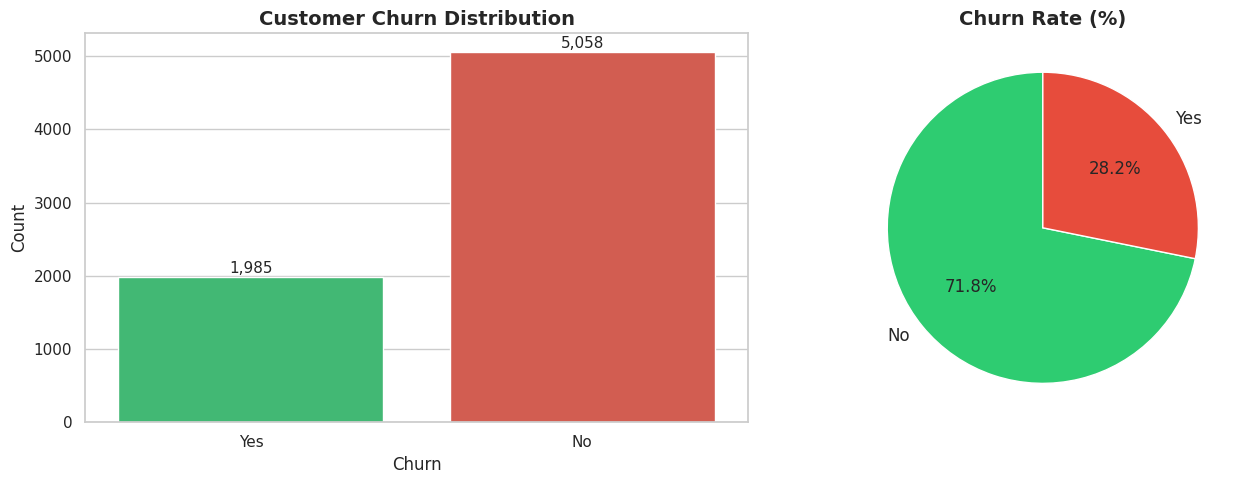

Churn rate: 28.2%


In [14]:
# Plot 1: Countplot for Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count
sns.countplot(data=df, x='Churn', palette=['#2ecc71','#e74c3c'], ax=axes[0])
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=11)

# Percentage pie
churn_counts = df['Churn'].value_counts()
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90, textprops={'fontsize':12})
axes[1].set_title('Churn Rate (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Churn rate: {df['Churn_enc'].mean()*100:.1f}%")


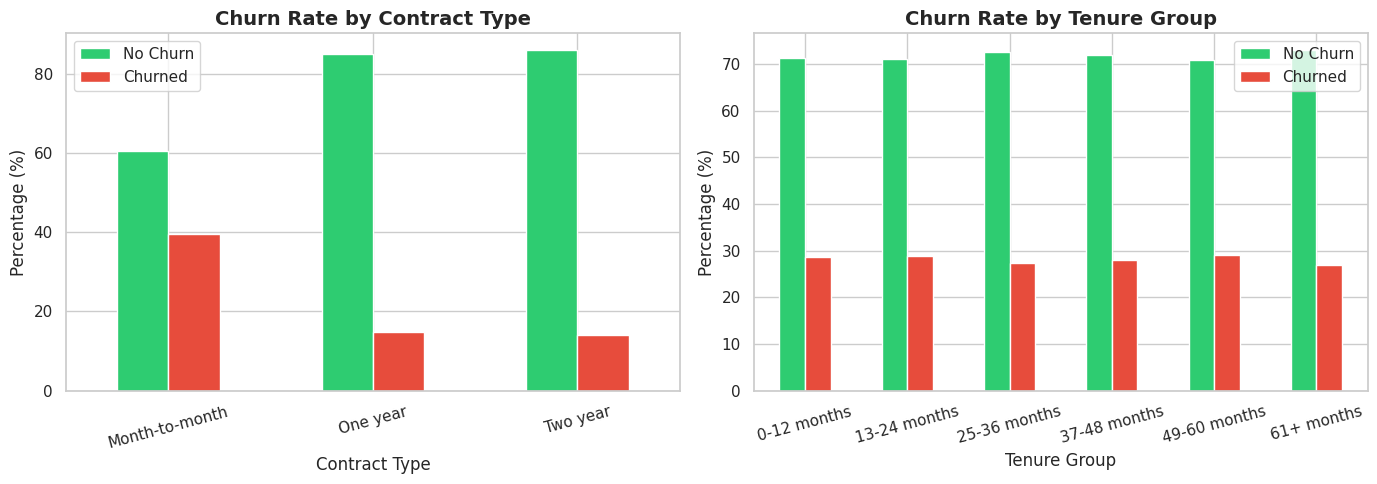

In [15]:
# Plot 2: Contract Type vs Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contract_churn = df.groupby(['Contract','Churn']).size().unstack(fill_value=0)
contract_churn_pct = contract_churn.div(contract_churn.sum(axis=1), axis=0) * 100

contract_churn_pct.plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], rot=15)
axes[0].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(['No Churn','Churned'])

# TenureGroup vs Churn
tenure_churn = df.groupby(['TenureGroup','Churn']).size().unstack(fill_value=0)
order = ['0-12 months','13-24 months','25-36 months','37-48 months','49-60 months','61+ months']
tenure_churn = tenure_churn.reindex(order)
tenure_pct = tenure_churn.div(tenure_churn.sum(axis=1), axis=0) * 100
tenure_pct.plot(kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'], rot=15)
axes[1].set_title('Churn Rate by Tenure Group', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tenure Group')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['No Churn','Churned'])

plt.tight_layout()
plt.savefig('contract_tenure_churn.png', dpi=100, bbox_inches='tight')
plt.show()


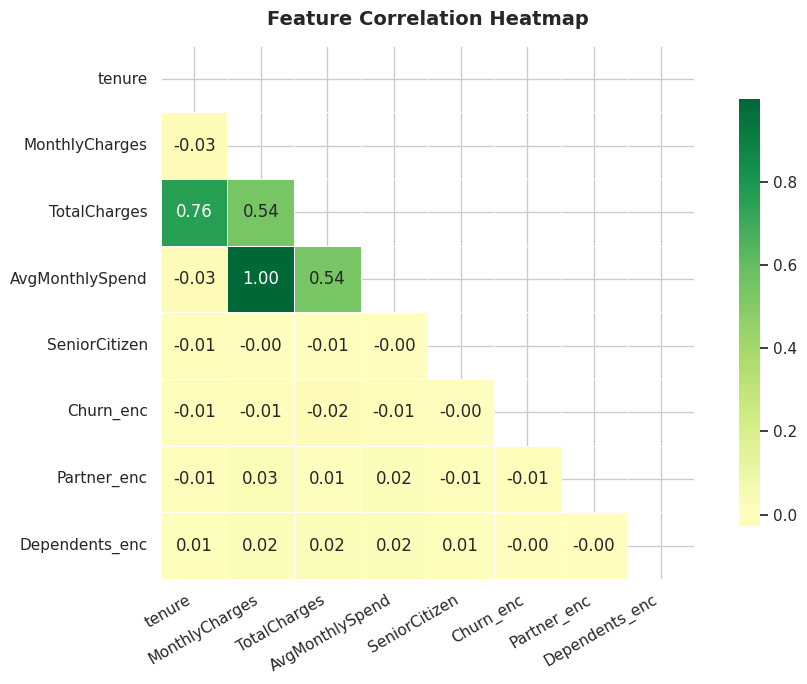

In [16]:
# Plot 3: Correlation Heatmap
numeric_cols = ['tenure','MonthlyCharges','TotalCharges','AvgMonthlySpend',
                'SeniorCitizen','Churn_enc','Partner_enc','Dependents_enc']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, linecolor='white',
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()


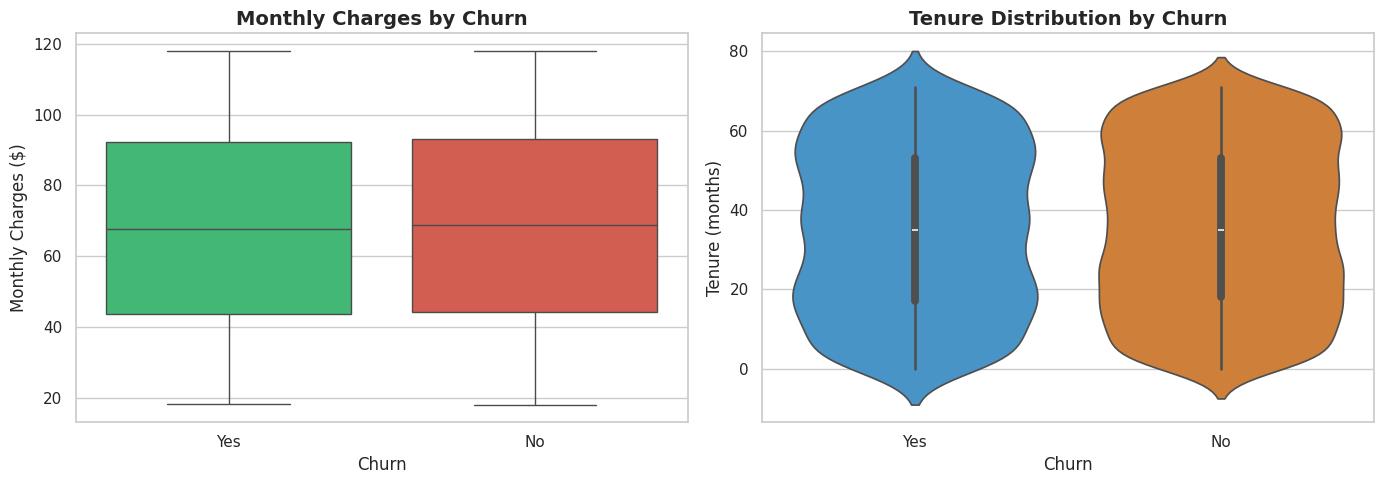

In [17]:
# Plot 4: Boxplot — MonthlyCharges by Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2ecc71','#e74c3c'], ax=axes[0])
axes[0].set_title('Monthly Charges by Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Monthly Charges ($)')

sns.violinplot(data=df, x='Churn', y='tenure', palette=['#3498db','#e67e22'], ax=axes[1])
axes[1].set_title('Tenure Distribution by Churn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tenure (months)')

plt.tight_layout()
plt.savefig('charges_tenure_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()


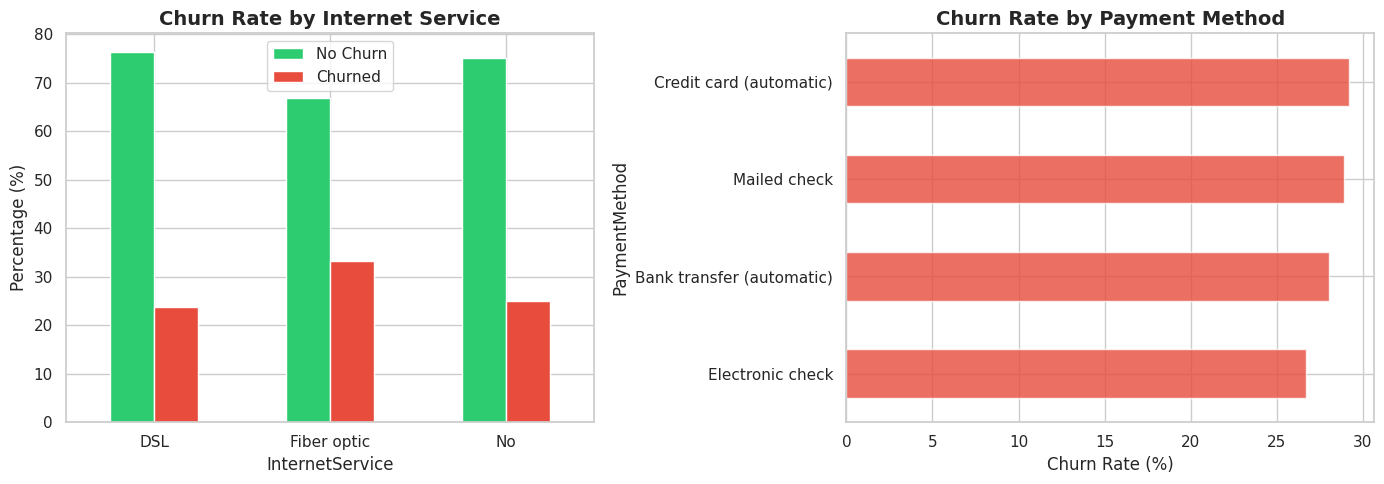

In [18]:
# Plot 5: Internet Service vs Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

internet_churn = df.groupby(['InternetService','Churn']).size().unstack(fill_value=0)
internet_pct = internet_churn.div(internet_churn.sum(axis=1), axis=0) * 100
internet_pct.plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], rot=0)
axes[0].set_title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(['No Churn','Churned'])

# Payment method vs churn
pay_churn = df.groupby(['PaymentMethod','Churn']).size().unstack(fill_value=0)
pay_pct = pay_churn.div(pay_churn.sum(axis=1), axis=0) * 100
pay_pct['Yes'].sort_values().plot(kind='barh', ax=axes[1], color='#e74c3c', alpha=0.8)
axes[1].set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('internet_payment_churn.png', dpi=100, bbox_inches='tight')
plt.show()


In [19]:
# Save cleaned dataset
df_clean = df.copy()
df_clean.to_csv('telco_churn_cleaned.csv', index=False)
print(f"✅ Cleaned dataset saved: telco_churn_cleaned.csv")
print(f"Shape: {df_clean.shape}")


✅ Cleaned dataset saved: telco_churn_cleaned.csv
Shape: (7043, 28)


## 5. 💡 Top 5 Insights

1. **High churn among Month-to-month customers (~42%)** — Customers without long-term contracts churn at nearly 3× the rate of two-year contract holders (~11%). Locking customers into longer contracts dramatically reduces churn.

2. **New customers are most at risk** — The 0–12 month tenure group shows the highest churn rate. This "onboarding window" is critical — a better early experience could significantly reduce early exits.

3. **Fiber Optic users churn more** — Despite being a premium service, Fiber Optic internet customers have a higher churn rate than DSL users. This may indicate unmet quality expectations or pricing concerns.

4. **Higher monthly charges correlate with churn** — Churned customers have a noticeably higher median MonthlyCharges (~$80 vs ~$61). Price sensitivity is a key driver of churn.

5. **Electronic check payment method = highest churn** — Customers paying via electronic check churn more than those using automatic bank transfers or credit cards. This could indicate lower commitment or dissatisfaction.
